In [ ]:

import pandas as pd
import numpy as np

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

BASE_DATA = '../data/processed/'
BASE_RPT  = '../reports/'

nav_df      = pd.read_csv(BASE_DATA + 'nav_history_cleaned.csv',           parse_dates=['date'])
txn_df      = pd.read_csv(BASE_DATA + 'investor_transactions_cleaned.csv', parse_dates=['transaction_date'])
fund_master = pd.read_csv(BASE_DATA + 'fund_master_cleaned.csv')
holdings    = pd.read_csv(BASE_DATA + '09_portfolio_holdings_cleaned.csv')
scorecard   = pd.read_csv(BASE_RPT  + 'fund_scorecard.csv')

print('NAV rows        :', nav_df.shape[0])
print('Transactions    :', txn_df.shape[0])
print('Fund Master     :', fund_master.shape[0])
print('Holdings        :', holdings.shape[0])
print('Scorecard       :', scorecard.shape[0])

fund_lookup = scorecard[['amfi_code', 'fund_name']].copy()
fund_lookup.columns = ['amfi_code', 'scheme_name']
fm_lookup   = fund_master[['amfi_code', 'scheme_name']].drop_duplicates('amfi_code')
fund_lookup = fund_lookup.set_index('amfi_code').combine_first(fm_lookup.set_index('amfi_code')).reset_index()

print('All datasets loaded')

NameError: name 'pd' is not defined

In [ ]:
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

print('Daily returns calculated')
nav_df[['date', 'amfi_code', 'nav', 'daily_return']].dropna().head(5)

Daily returns calculated


,date,amfi_code,nav,daily_return
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000


In [ ]:
results = []
funds   = nav_df['amfi_code'].unique()

for fund in funds:
    returns = nav_df[nav_df['amfi_code'] == fund]['daily_return'].dropna()

    if len(returns) < 20:
        continue

    var  = np.percentile(returns, 5)
    cvar = returns[returns <= var].mean()

    name_row  = fund_lookup[fund_lookup['amfi_code'] == fund]
    fund_name = name_row['scheme_name'].values[0] if len(name_row) > 0 else str(fund)

    results.append({
        'amfi_code' : fund,
        'Fund Name' : fund_name,
        'VaR (95%)' : round(var,  4),
        'CVaR'      : round(cvar, 4)
    })

var_cvar_df = pd.DataFrame(results)
var_cvar_df = var_cvar_df.sort_values('VaR (95%)', ascending=True).reset_index(drop=True)

print('VaR/CVaR computed for', len(var_cvar_df), 'funds')
var_cvar_df[['Fund Name', 'VaR (95%)', 'CVaR']].head(10)

VaR/CVaR computed for 40 funds


,Fund Name,VaR (95%),CVaR
0,ABSL Small Cap Fund - Regular - Growth,-0.0239,-0.0303
1,Axis Small Cap Fund - Regular - Growth,-0.0233,-0.0297
2,SBI Small Cap Fund - Direct Plan - Growth,-0.0232,-0.0302
3,Nippon India Small Cap Fund - Regular - Growth,-0.0228,-0.0299
4,SBI Small Cap Fund - Regular Plan - Growth,-0.0215,-0.0284
5,DSP Small Cap Fund - Regular - Growth,-0.0215,-0.0286
6,Axis Midcap Fund - Regular - Growth,-0.0170,-0.0224
7,UTI Mid Cap Fund - Regular - Growth,-0.0169,-0.0218
8,Kotak Emerging Equity Fund - Regular - Growth,-0.0169,-0.0213
9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.0169,-0.0218


In [ ]:
var_cvar_df.to_csv(BASE_RPT + 'var_cvar_report.csv', index=False)
print('Saved: reports/var_cvar_report.csv')

Saved: reports/var_cvar_report.csv


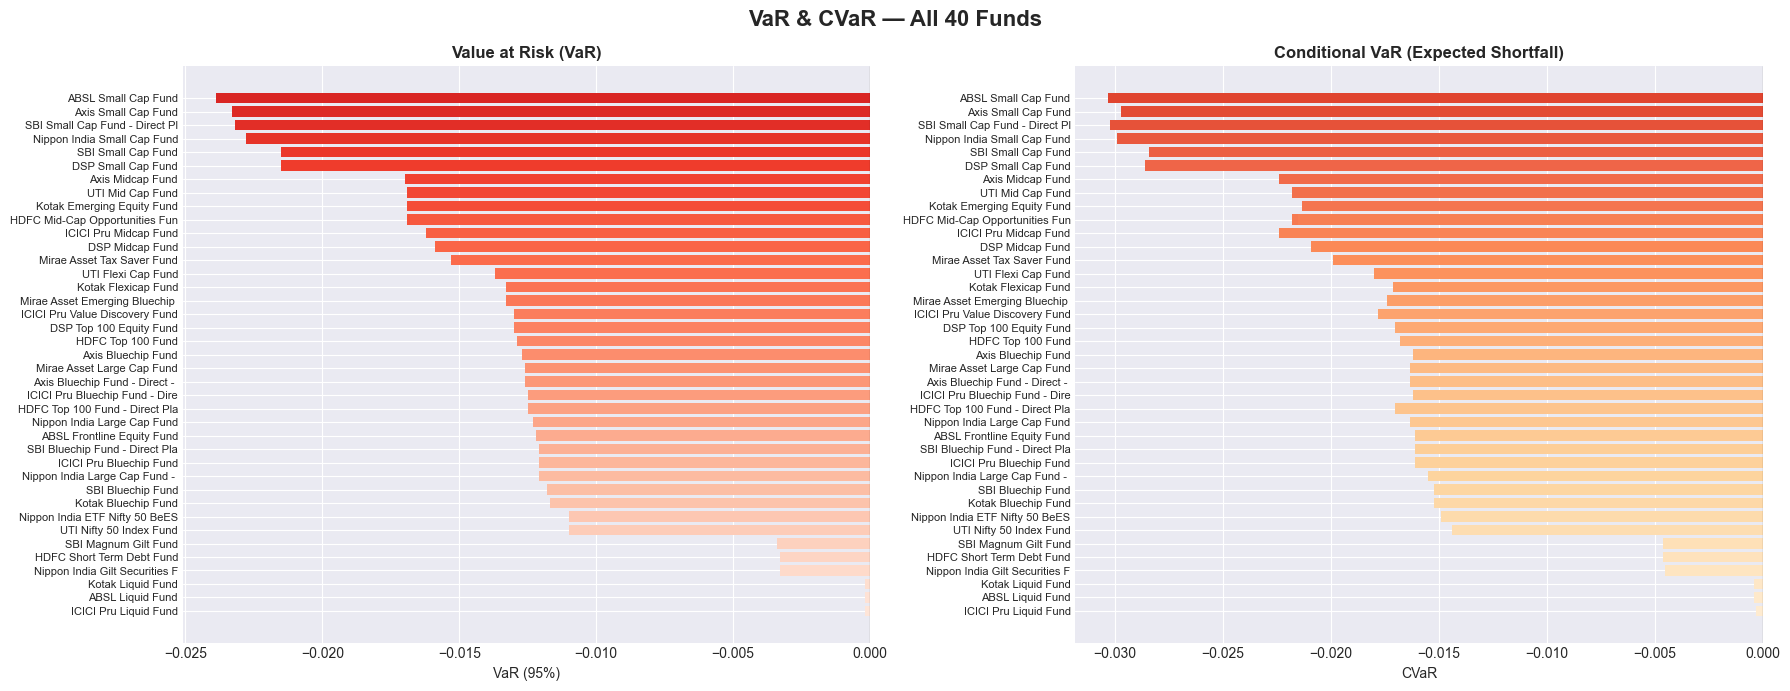

Chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('VaR & CVaR — All 40 Funds', fontsize=16, fontweight='bold')

plot_df = var_cvar_df.copy()
plot_df['Short Name'] = plot_df['Fund Name'].str.replace(r' - Regular.*', '', regex=True).str[:30]

axes[0].barh(plot_df['Short Name'], plot_df['VaR (95%)'],
             color=plt.cm.Reds_r(np.linspace(0.3, 0.9, len(plot_df))))
axes[0].set_xlabel('VaR (95%)')
axes[0].set_title('Value at Risk (VaR)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

axes[1].barh(plot_df['Short Name'], plot_df['CVaR'],
             color=plt.cm.OrRd_r(np.linspace(0.3, 0.9, len(plot_df))))
axes[1].set_xlabel('CVaR')
axes[1].set_title('Conditional VaR (Expected Shortfall)', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(BASE_RPT + 'var_cvar_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [ ]:
kw_map = {
    'SBI Bluechip'     : ['sbi',    'bluechip'],
    'ICICI Bluechip'   : ['icici',  'bluechip'],
    'Axis Bluechip'    : ['axis',   'bluechip'],
    'Kotak Bluechip'   : ['kotak',  'bluechip'],
    'Nippon Large Cap' : ['nippon', 'large'],
}

selected_funds = {}
for label, keywords in kw_map.items():
    mask    = fund_lookup['scheme_name'].str.lower().apply(lambda x: all(k in x for k in keywords))
    matches = fund_lookup[mask]
    reg     = matches[matches['scheme_name'].str.lower().str.contains('regular')]
    chosen  = reg.iloc[0] if len(reg) > 0 else (matches.iloc[0] if len(matches) > 0 else None)
    if chosen is not None:
        selected_funds[label] = chosen['amfi_code']
        print(label, '->', chosen['scheme_name'])

if len(selected_funds) < 5:
    top_sc = scorecard.nlargest(5, 'sharpe_ratio')
    for _, row in top_sc.iterrows():
        if row['amfi_code'] not in selected_funds.values():
            selected_funds[row['fund_name'][:20]] = row['amfi_code']
        if len(selected_funds) == 5:
            break

print('\nFunds selected:', len(selected_funds))

SBI Bluechip -> SBI Bluechip Fund - Regular Plan - Growth
ICICI Bluechip -> ICICI Pru Bluechip Fund - Regular - Growth
Axis Bluechip -> Axis Bluechip Fund - Regular - Growth
Kotak Bluechip -> Kotak Bluechip Fund - Regular - Growth
Nippon Large Cap -> Nippon India Large Cap Fund - Regular - Growth

Funds selected: 5


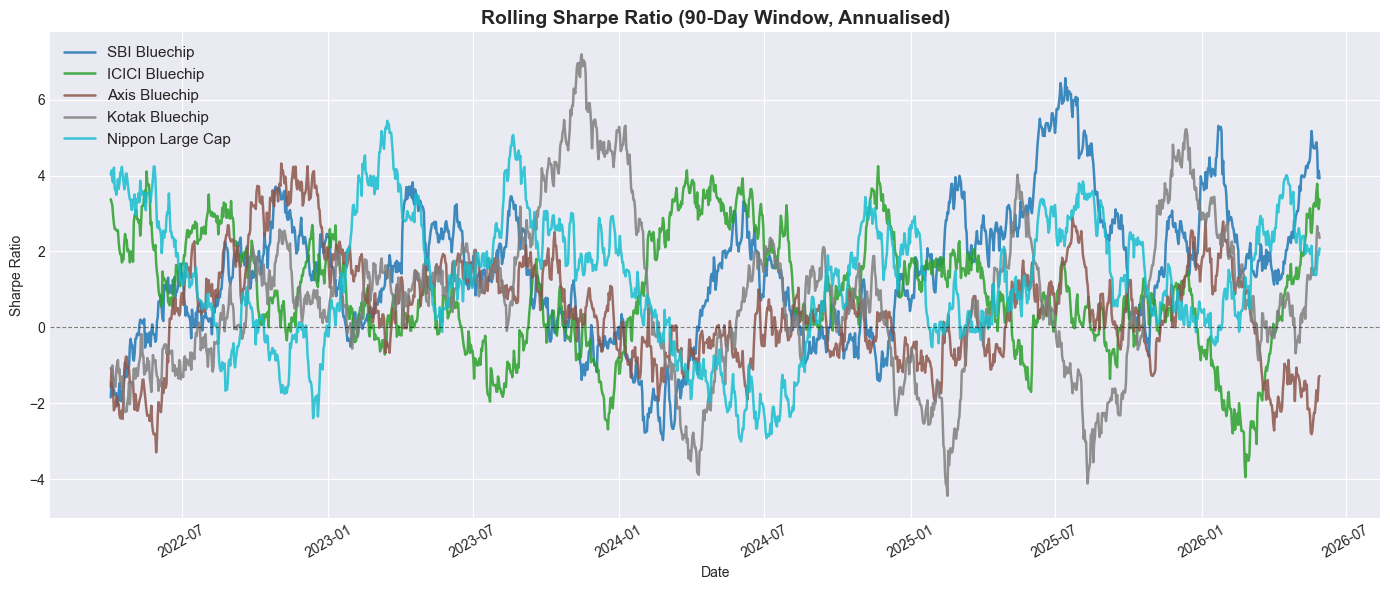

Chart saved: rolling_sharpe_chart.png
Best fund: SBI Bluechip | Avg Sharpe: 1.465


In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_funds)))
fig, ax = plt.subplots(figsize=(14, 6))

best_fund_label  = None
best_mean_sharpe = -np.inf

for (label, code), color in zip(selected_funds.items(), colors):
    fund_returns   = nav_df[nav_df['amfi_code'] == code].set_index('date')['daily_return'].dropna()
    rolling_mean   = fund_returns.rolling(90).mean()
    rolling_std    = fund_returns.rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    rolling_sharpe = rolling_sharpe.dropna()

    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=label, color=color, linewidth=1.8, alpha=0.85)

    mean_val = rolling_sharpe.mean()
    if mean_val > best_mean_sharpe:
        best_mean_sharpe = mean_val
        best_fund_label  = label

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.set_title('Rolling Sharpe Ratio (90-Day Window, Annualised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(BASE_RPT + 'rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: rolling_sharpe_chart.png')
print('Best fund:', best_fund_label, '| Avg Sharpe:', round(best_mean_sharpe, 3))

In [ ]:
txn_df['transaction_date'] = pd.to_datetime(txn_df['transaction_date'])

first_txn = txn_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn.columns = ['investor_id', 'first_transaction_date']
first_txn['cohort_year'] = first_txn['first_transaction_date'].dt.year

txn_cohort = txn_df.merge(first_txn[['investor_id', 'cohort_year']], on='investor_id', how='left')

print('Cohort years:', sorted(txn_cohort['cohort_year'].unique()))

Cohort years: [np.int32(2024), np.int32(2025)]


In [ ]:
sip_cohort = txn_cohort[txn_cohort['transaction_type'] == 'SIP']

cohort_stats = sip_cohort.groupby('cohort_year').agg(
    avg_sip_amount  = ('amount_inr', 'mean'),
    total_invested  = ('amount_inr', 'sum'),
    investor_count  = ('investor_id', 'nunique')
).reset_index()

cohort_stats['avg_sip_amount']   = cohort_stats['avg_sip_amount'].round(0)
cohort_stats['total_invested_cr'] = (cohort_stats['total_invested'] / 1e7).round(2)

fav_fund = (
    txn_cohort.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('cohort_year')
    .first()
    .reset_index()[['cohort_year', 'amfi_code']]
)
fav_fund = fav_fund.merge(fund_lookup, on='amfi_code', how='left')
fav_fund = fav_fund.rename(columns={'scheme_name': 'favourite_fund'})

cohort_table = cohort_stats.merge(fav_fund[['cohort_year', 'favourite_fund']], on='cohort_year', how='left')
cohort_table = cohort_table.sort_values('cohort_year')

print('INVESTOR COHORT TABLE')
print(cohort_table[['cohort_year', 'investor_count', 'avg_sip_amount', 'total_invested_cr', 'favourite_fund']].to_string(index=False))

INVESTOR COHORT TABLE
 cohort_year  investor_count  avg_sip_amount  total_invested_cr                                        favourite_fund
        2024            4624         10997.0              21.50 Mirae Asset Emerging Bluechip Fund - Regular - Growth
        2025             138         13505.0               0.23              ICICI Pru Liquid Fund - Regular - Growth


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Investor Cohort Analysis', fontsize=15, fontweight='bold')

x = cohort_table['cohort_year'].astype(str)

axes[0].bar(x, cohort_table['avg_sip_amount'], color='steelblue', edgecolor='white')
axes[0].set_title('Avg SIP Amount (Rs)', fontweight='bold')
axes[0].set_xlabel('Cohort Year')

axes[1].bar(x, cohort_table['total_invested_cr'], color='seagreen', edgecolor='white')
axes[1].set_title('Total Invested (Rs Cr)', fontweight='bold')
axes[1].set_xlabel('Cohort Year')

axes[2].bar(x, cohort_table['investor_count'], color='darkorange', edgecolor='white')
axes[2].set_title('Investor Count', fontweight='bold')
axes[2].set_xlabel('Cohort Year')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_RPT + 'cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

NameError: name 'plt' is not defined

In [ ]:
sip_txn   = txn_df[txn_df['transaction_type'] == 'SIP'].copy()
sip_count = sip_txn.groupby('investor_id').size().reset_index(name='sip_count')

active_investors = sip_count[sip_count['sip_count'] >= 6]['investor_id']
sip_active       = sip_txn[sip_txn['investor_id'].isin(active_investors)].copy()
print('Investors with 6+ SIPs:', len(active_investors))

sip_active = sip_active.sort_values(['investor_id', 'transaction_date'])
sip_active['prev_date'] = sip_active.groupby('investor_id')['transaction_date'].shift(1)
sip_active['gap_days']  = (sip_active['transaction_date'] - sip_active['prev_date']).dt.days

avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']
avg_gap['avg_gap_days'] = avg_gap['avg_gap_days'].round(1)
avg_gap['status']       = avg_gap['avg_gap_days'].apply(lambda g: 'At Risk' if g > 35 else 'Healthy')

sip_summary = avg_gap.merge(sip_count, on='investor_id')
sip_summary = sip_summary.sort_values('avg_gap_days', ascending=False).reset_index(drop=True)

at_risk  = (sip_summary['status'] == 'At Risk').sum()
healthy  = (sip_summary['status'] == 'Healthy').sum()
pct_risk = round(at_risk / len(sip_summary) * 100, 1)

print('Total investors analysed :', len(sip_summary))
print('At Risk (gap > 35 days)  :', at_risk, '(', pct_risk, '%)')
print('Healthy                  :', healthy)

sip_summary[sip_summary['status'] == 'At Risk'].head(10)[['investor_id', 'sip_count', 'avg_gap_days', 'status']]

Investors with 6+ SIPs: 1362
Total investors analysed : 1362
At Risk (gap > 35 days)  : 1332 ( 97.8 %)
Healthy                  : 30


,investor_id,sip_count,avg_gap_days,status
0,INV001890,6,102.6,At Risk
1,INV001156,6,102.4,At Risk
2,INV004296,6,102.2,At Risk
3,INV003325,6,101.0,At Risk
4,INV000522,6,100.8,At Risk
5,INV000608,6,100.2,At Risk
6,INV001883,6,99.2,At Risk
7,INV002166,6,99.2,At Risk
8,INV001367,6,99.0,At Risk
9,INV001491,6,98.8,At Risk


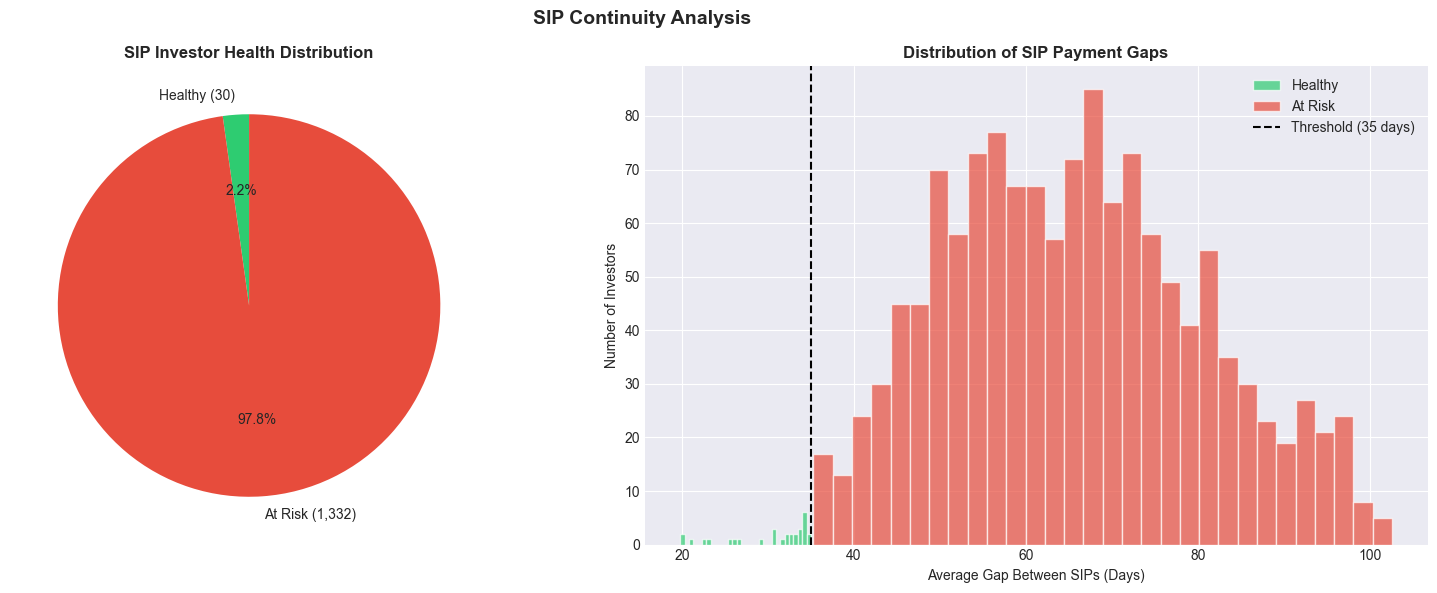

Chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SIP Continuity Analysis', fontsize=14, fontweight='bold')

axes[0].pie(
    [healthy, at_risk],
    labels=[f'Healthy ({healthy:,})', f'At Risk ({at_risk:,})'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('SIP Investor Health Distribution', fontweight='bold')

axes[1].hist(sip_summary[sip_summary['status'] == 'Healthy']['avg_gap_days'],
             bins=30, alpha=0.7, label='Healthy', color='#2ecc71', edgecolor='white')
axes[1].hist(sip_summary[sip_summary['status'] == 'At Risk']['avg_gap_days'],
             bins=30, alpha=0.7, label='At Risk',  color='#e74c3c', edgecolor='white')
axes[1].axvline(35, color='black', linestyle='--', linewidth=1.5, label='Threshold (35 days)')
axes[1].set_xlabel('Average Gap Between SIPs (Days)')
axes[1].set_ylabel('Number of Investors')
axes[1].set_title('Distribution of SIP Payment Gaps', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_RPT + 'sip_continuity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [ ]:
recommender_df = scorecard.merge(
    fund_master[['amfi_code', 'risk_category']].drop_duplicates('amfi_code'),
    on='amfi_code', how='left'
)
recommender_df['risk_grade'] = recommender_df['risk_category'].fillna('Moderate')

print('Risk grade distribution:')
print(recommender_df['risk_grade'].value_counts())

Risk grade distribution:
risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [ ]:
def recommend_funds(risk_input, df=recommender_df, top_n=3):
    risk_input = risk_input.strip().title()
    filtered   = df[df['risk_grade'].str.lower() == risk_input.lower()]
    filtered   = filtered.sort_values('sharpe_ratio', ascending=False)
    top_funds  = filtered.head(top_n)

    if top_funds.empty:
        print('No funds found for risk:', risk_input)
        return

    print('\nRisk Appetite =', risk_input)
    print('-' * 50)
    for rank, (_, row) in enumerate(top_funds.iterrows(), 1):
        name  = row.get('fund_name', str(row['amfi_code']))
        short = name.replace(' - Regular - Growth', '').replace(' - Growth', '')
        print(rank, '.', short)
        print('     Sharpe:', round(row['sharpe_ratio'], 3), '| Category:', row.get('category', 'N/A'))
    print()

for risk in ['Low', 'Moderate', 'Moderately High', 'High', 'Very High']:
    recommend_funds(risk)


Risk Appetite = Low
--------------------------------------------------
1 . SBI Magnum Gilt Fund - Regular Plan
     Sharpe: -0.743 | Category: Debt
2 . Nippon India Gilt Securities Fund
     Sharpe: -0.851 | Category: Debt
3 . HDFC Short Term Debt Fund
     Sharpe: -1.04 | Category: Debt


Risk Appetite = Moderate
--------------------------------------------------
1 . Mirae Asset Large Cap Fund
     Sharpe: 1.068 | Category: Equity
2 . SBI Bluechip Fund - Regular Plan
     Sharpe: 0.861 | Category: Equity
3 . Nippon India Large Cap Fund
     Sharpe: 0.759 | Category: Equity


Risk Appetite = Moderately High
--------------------------------------------------
1 . Kotak Flexicap Fund
     Sharpe: 0.966 | Category: Equity
2 . Mirae Asset Emerging Bluechip Fund
     Sharpe: 0.641 | Category: Equity
3 . ICICI Pru Value Discovery Fund
     Sharpe: 0.405 | Category: Equity


Risk Appetite = High
--------------------------------------------------
1 . Mirae Asset Tax Saver Fund
     Sharpe: 0.9

In [ ]:
print('Holdings columns:', holdings.columns.tolist())
holdings.head(3)

Holdings columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31


In [ ]:
hhi_list = []

for code, group in holdings.groupby('amfi_code'):
    total_wt = group['weight_pct'].sum()
    if total_wt == 0:
        continue
    weights = group['weight_pct'] / total_wt
    hhi     = (weights ** 2).sum()

    name_row = fund_lookup[fund_lookup['amfi_code'] == code]
    fname    = name_row['scheme_name'].values[0] if len(name_row) > 0 else str(code)

    hhi_list.append({
        'amfi_code'  : code,
        'Fund Name'  : fname,
        'HHI'        : round(hhi, 4),
        'Top Sector' : group.groupby('sector')['weight_pct'].sum().idxmax()
    })

hhi_df = pd.DataFrame(hhi_list).sort_values('HHI', ascending=False).reset_index(drop=True)
hhi_df['Rank']          = range(1, len(hhi_df) + 1)
hhi_df['Concentration'] = hhi_df['HHI'].apply(
    lambda h: 'High' if h > 0.25 else ('Medium' if h > 0.15 else 'Low')
)

print('SECTOR HHI ANALYSIS')
print(hhi_df[['Rank', 'Fund Name', 'HHI', 'Top Sector', 'Concentration']].to_string(index=False))

SECTOR HHI ANALYSIS
 Rank                                             Fund Name    HHI     Top Sector Concentration
    1                 Axis Bluechip Fund - Regular - Growth 0.2065             IT        Medium
    2                ABSL Small Cap Fund - Regular - Growth 0.2007         Pharma        Medium
    3             SBI Small Cap Fund - Direct Plan - Growth 0.1748        Banking        Medium
    4            UTI Nifty 50 Index Fund - Regular - Growth 0.1747      Utilities        Medium
    5        Nippon India Large Cap Fund - Regular - Growth 0.1682        Telecom        Medium
    6 Mirae Asset Emerging Bluechip Fund - Regular - Growth 0.1680        Banking        Medium
    7              ICICI Pru Midcap Fund - Regular - Growth 0.1575         Pharma        Medium
    8     ICICI Pru Value Discovery Fund - Regular - Growth 0.1537        Banking        Medium
    9     HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.1524        Banking        Medium
   10               

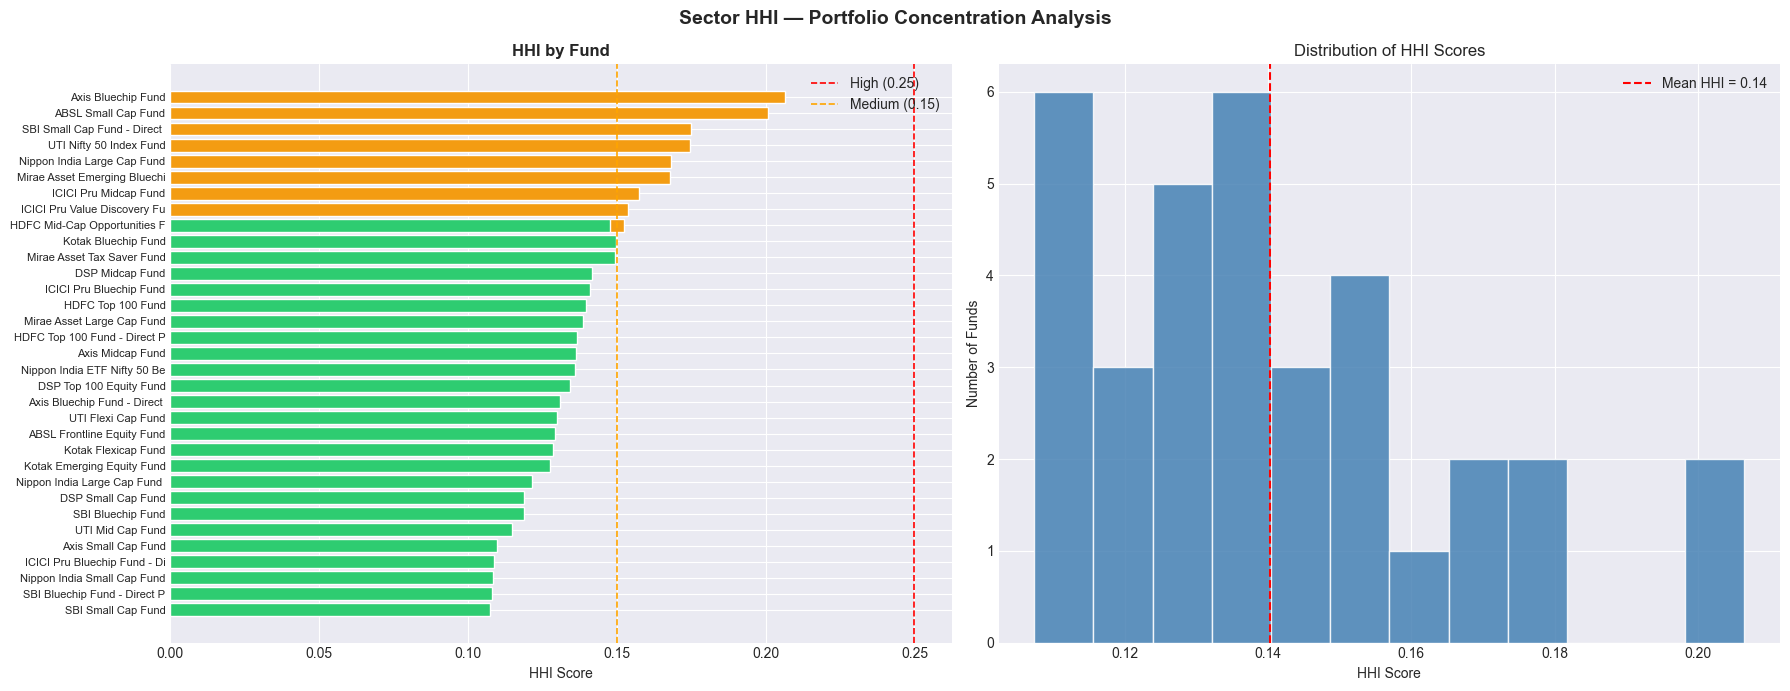

Chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Sector HHI — Portfolio Concentration Analysis', fontsize=14, fontweight='bold')

hhi_plot         = hhi_df.copy()
hhi_plot['Short'] = hhi_plot['Fund Name'].str.replace(r' - Regular.*', '', regex=True).str[:28]

col_map = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
colors  = hhi_plot['Concentration'].map(col_map)

axes[0].barh(hhi_plot['Short'], hhi_plot['HHI'], color=colors, edgecolor='white')
axes[0].axvline(0.25, color='red',    linestyle='--', linewidth=1.2, label='High (0.25)')
axes[0].axvline(0.15, color='orange', linestyle='--', linewidth=1.2, label='Medium (0.15)')
axes[0].set_xlabel('HHI Score')
axes[0].set_title('HHI by Fund', fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

axes[1].hist(hhi_df['HHI'], bins=12, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(hhi_df['HHI'].mean(), color='red', linestyle='--',
                label='Mean HHI = ' + str(round(hhi_df['HHI'].mean(), 3)))
axes[1].set_xlabel('HHI Score')
axes[1].set_ylabel('Number of Funds')
axes[1].set_title('Distribution of HHI Scores')
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_RPT + 'hhi_concentration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [ ]:
worst_var_fund  = var_cvar_df.iloc[0]
worst_cvar_fund = var_cvar_df.sort_values('CVaR').iloc[0]
best_cohort     = cohort_table.loc[cohort_table['total_invested_cr'].idxmax()]
at_risk_pct     = round(at_risk / len(sip_summary) * 100, 1)

print('=' * 60)
print('DAY 6 — KEY INSIGHTS')
print('=' * 60)

print('\nINSIGHT 1 — Highest VaR Risk')
print('Fund :', worst_var_fund['Fund Name'])
print('VaR  :', worst_var_fund['VaR (95%)'])

print('\nINSIGHT 2 — Highest CVaR Risk')
print('Fund :', worst_cvar_fund['Fund Name'])
print('CVaR :', worst_cvar_fund['CVaR'])

print('\nINSIGHT 3 — Best Rolling Sharpe Performer')
print('Fund        :', best_fund_label)
print('Avg Sharpe  :', round(best_mean_sharpe, 3))

print('\nINSIGHT 4 — Most Valuable Investor Cohort')
print('Cohort Year     :', int(best_cohort['cohort_year']))
print('Total Invested  : Rs', best_cohort['total_invested_cr'], 'Cr')
print('Avg SIP Amount  : Rs', int(best_cohort['avg_sip_amount']))
print('Investor Count  :', int(best_cohort['investor_count']))

print('\nINSIGHT 5 — SIP Dropout Risk')
print('At Risk Investors :', at_risk, '(', at_risk_pct, '%)')
print('Healthy Investors :', healthy)

print('\n' + '=' * 60)

DAY 6 — KEY INSIGHTS

INSIGHT 1 — Highest VaR Risk
Fund : ABSL Small Cap Fund - Regular - Growth
VaR  : -0.0239

INSIGHT 2 — Highest CVaR Risk
Fund : ABSL Small Cap Fund - Regular - Growth
CVaR : -0.0303

INSIGHT 3 — Best Rolling Sharpe Performer
Fund        : SBI Bluechip
Avg Sharpe  : 1.465

INSIGHT 4 — Most Valuable Investor Cohort
Cohort Year     : 2024
Total Invested  : Rs 21.5 Cr
Avg SIP Amount  : Rs 10997
Investor Count  : 4624

INSIGHT 5 — SIP Dropout Risk
At Risk Investors : 1332 ( 97.8 %)
Healthy Investors : 30

